In [1]:
#export
import k1lib, dill, numpy as np, pprint, html, math, time; k1 = k1lib; requests = k1.dep("requests"); cli = k1.cli
from io import BytesIO; from PIL import Image
import matplotlib.pyplot as plt

A bunch of code here was written by ChatGPT, cause I'm too lazy. But it appears to have done the job really well

In [2]:
#export
__all__ = ["optimalZoom", "dist", "area", "polyArea", "tile", "elevMatrix", "sat", "elev", "satElev"]

In [3]:
#export
def tilesCb(s,v): fetch_tile.cacheObj.fn = v
k1.settings.add("kgis", k1.Settings()
    .add("tiles", k1.Settings()
        .add("prefix", "https://mt0.google.com/vt/lyrs=s", "the string '&x={x}&y={y}&z={z}' will be added to this prefix to create a url to query tile images")
        .add("sqliteFile", "tiles.db", "sqlite file path to cache google maps tile images to", cb=tilesCb)
    , "gg maps tiles docs")
, "kgis-related module")
settings = k1.settings.kgis; settings

Settings:                                              
- tiles = <Settings>                                   ​      ​gg maps tiles docs                                                                                     
  - prefix     = https://mt0.google.com/vt/lyrs=s      ​      ​the string '&x={x}&y={y}&z={z}' will be added to this prefix to create a url to query tile images      
  - sqliteFile = tiles.db                              ​      ​sqlite file path to cache google maps tile images to                                                   
                                                       

In [51]:
#export
TILE_SIZE = 256
def latlon_to_tile_xy(lat:float, lon:float, zoom:int): lat_rad = math.radians(lat); n = 2 ** zoom; xtile = int((lon + 180.0) / 360.0 * n); ytile = int((1.0 - math.log(math.tan(lat_rad) + 1 / math.cos(lat_rad)) / math.pi) / 2.0 * n); return xtile, ytile
def tile_xy_to_pixel_xy(x, y): return x * TILE_SIZE, y * TILE_SIZE
def latlon_to_pixel_xy(lat, lon, zoom): lat_rad = math.radians(lat); n = 2 ** zoom; x = (lon + 180.0) / 360.0 * n * TILE_SIZE; y = (1.0 - math.log(math.tan(lat_rad) + 1 / math.cos(lat_rad)) / math.pi) / 2.0 * n * TILE_SIZE; return int(x), int(y)
@k1.cache(timeout=0, maxsize=100_000, fn=settings.tiles.sqliteFile, pickle=(cli.toBytes(), cli.toImg()))
def fetch_tile(x, y, z): response = requests.get(f"{settings.tiles.prefix}&x={x}&y={y}&z={z}"); response.raise_for_status(); return Image.open(BytesIO(response.content))
def tile(x, y, z):
    """Grabs google maps tiles"""
    return fetch_tile(x,y,z)
def get_satellite_image(top_left, bottom_right, target_width_px=1000, zoom=None):
    """Grabs satellite image of terrain"""
    if zoom is None: zoom = optimalZoom(top_left, bottom_right, target_width_px)
    xtile_min, ytile_min = latlon_to_tile_xy(top_left[0], top_left[1], zoom); xtile_max, ytile_max = latlon_to_tile_xy(bottom_right[0], bottom_right[1], zoom)
    width = (xtile_max - xtile_min + 1) * TILE_SIZE; height = (ytile_max - ytile_min + 1) * TILE_SIZE; stitched = Image.new("RGB", (width, height))
    for x in range(xtile_min, xtile_max + 1):
        for y in range(ytile_min, ytile_max + 1): tile = fetch_tile(x, y, zoom); stitched.paste(tile, ( (x - xtile_min) * TILE_SIZE, (y - ytile_min) * TILE_SIZE ))
    pixel_min = latlon_to_pixel_xy(top_left[0], top_left[1], zoom); pixel_max = latlon_to_pixel_xy(bottom_right[0], bottom_right[1], zoom)
    left = pixel_min[0] - xtile_min * TILE_SIZE; upper = pixel_min[1] - ytile_min * TILE_SIZE; right = pixel_max[0] - xtile_min * TILE_SIZE; lower = pixel_max[1] - ytile_min * TILE_SIZE
    return stitched.crop((left, upper, right, lower))
def optimalZoom(top_left, bottom_right, target_width_px=1000):
    """Calculates what's the optimal zoom to request elevation tiles. Subtract 2 to get nice display zoom"""
    lon_diff = abs(bottom_right[1] - top_left[1]); center_lat = (top_left[0] + bottom_right[0]) / 2.0
    for z in range(1, 22):
        n = 2 ** z; pixel_width = lon_diff * (n * TILE_SIZE / 360.0); pixel_width *= math.cos(math.radians(center_lat)) # Adjust for latitude distortion in Mercator projection
        if pixel_width > target_width_px: return z - 1 if z > 1 else 1
    return 21  # fallback to max zoom
def correctCoords(top_left, bottom_right): latMin = min(top_left[0], bottom_right[0]); latMax = max(top_left[0], bottom_right[0]); lngMin = min(top_left[1], bottom_right[1]); lngMax = max(top_left[1], bottom_right[1]); return (latMax, lngMin), (latMin, lngMax)
def dist(top_left:"(float, float)", bottom_right:"(float, float)") -> float:
    """Calculates haversine distance in meters between 2 points"""
    (lat1, lon1), (lat2, lon2) = correctCoords(top_left, bottom_right)
    R = 6371000; lat1_rad, lat2_rad = math.radians(lat1), math.radians(lat2); delta_lat = lat2_rad - lat1_rad; delta_lon = math.radians(lon2 - lon1)
    a = math.sin(delta_lat / 2) ** 2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(delta_lon / 2) ** 2; return 2 * R * math.asin(math.sqrt(a))
def area(top_left:"(float, float)", bottom_right:"(float, float)") -> float:
    """Grab area in m2 of the specified region"""
    (lat1, lon1), (lat2, lon2) = correctCoords(top_left, bottom_right); height = dist((lat1, lon1), (lat2, lon1)); width = dist((lat1, lon1), (lat1, lon2)); return width * height
def polyArea(latlng_points):
    """Approximates the area of a polygon on Earth using the spherical excess formula."""
    if len(latlng_points) < 3: return 0.0  # Not a polygon
    def deg2rad(deg): return deg * math.pi / 180
    R = 6371000; total = 0.0
    for i in range(len(latlng_points)):
        lat1, lon1 = latlng_points[i - 1]; lat2, lon2 = latlng_points[i]
        lat1 = deg2rad(lat1); lat2 = deg2rad(lat2); lon1 = deg2rad(lon1); lon2 = deg2rad(lon2)
        total += (lon2 - lon1) * (2 + math.sin(lat1) + math.sin(lat2))
    return abs(total) * (R ** 2) / 2

In [57]:
settings.tiles.sqliteFile = "tests/tiles.db"

In [58]:
top_left, bottom_right = (12.689912, 108.065761), (12.686967, 108.070033)
assert dist(top_left, bottom_right) == 567.4485645379137
assert area(top_left, bottom_right) == 151756.17308743138

CPU times: user 3.74 ms, sys: 38.8 ms, total: 42.6 ms
Wall time: 160 ms


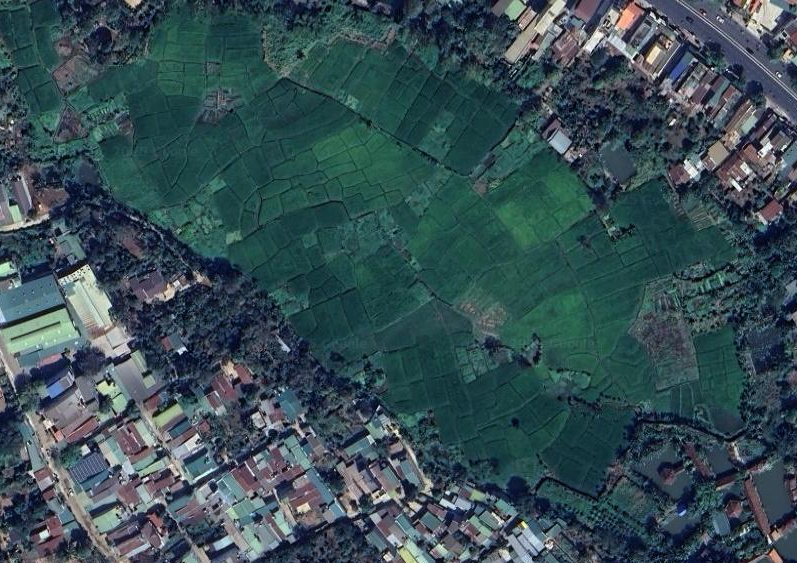

In [59]:
%%time
get_satellite_image(top_left, bottom_right, 1000)

In [25]:
#export
def elevCb(s,v): get_tile_elevation.cacheObj.fn = v
settings.add("elev", k1.Settings()
             .add("gpxzApiKey", "fillInHere", "api key to use https://www.gpxz.io/'s service", env="GPXZ_API_KEY", sensitive=True)
             .add("prod", True, "whether to actually call the api or just return some dummy elevation data instead")
             .add("sqliteFile", "elevs.db", "sqlite file path to cache elevation calls", cb=elevCb)
, "all settings related to getting elevations of a particular area")
def _elevationFunc(latlngs:"list[(float, float)]") -> list[float]: # can swap with different implementation
    if settings.elev.prod:
        ans = []
        for a in latlngs | ~cli.apply(lambda x,y: f"{x},{y}") | cli.batched(512, True) | cli.join("|").all():
            res = requests.post('https://api.gpxz.io/v1/elevation/points', headers={'x-api-key': settings.elev.gpxzApiKey}, data={'latlons': a})
            res.raise_for_status(); ans.extend([x["elevation"] for x in res.json()["results"]]); time.sleep(1)
        return ans
    else: freq = 100; return [math.cos(lat*freq) + math.sin(lng*freq) for lat,lng in latlngs]
elevationFunc = [_elevationFunc]; elevations = {} # maps from (int,int,int) -> float
def registerElevationFunc(f): elevationFunc[0] = f # there's this function that's supposed to be exposed, but too lazy to explain everything, so just leave this mechanism private
def tile_to_latlon(x, y, z): n = 2.0 ** z; lon = x / n * 360.0 - 180.0; lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * y / n))); lat = math.degrees(lat_rad); return lat, lon
def latlon_to_tile_xy(lat, lon, zoom): lat_rad = math.radians(lat); n = 2 ** zoom; xtile = int((lon + 180.0) / 360.0 * n); ytile = int((1.0 - math.log(math.tan(lat_rad) + 1 / math.cos(lat_rad)) / math.pi) / 2.0 * n); return xtile, ytile
@k1.cache(timeout=0, maxsize=10_000_000, fn=settings.elev.sqliteFile)
def get_tile_elevation(x,y,z):
    key = (x,y,z)
    if key in elevations: return elevations[key]
    else: return get_tile_elevations([(x,y,z)])[0]
def get_tile_elevations(xyzs:"list[(int, int, int)]") -> "list[float]":
    latlngs = [[i, (x,y,z), tile_to_latlon(x, y, z)] for i,[x,y,z] in enumerate(xyzs)]
    hasKeys = [[i,get_tile_elevation(*key)] for i,key,latlng in latlngs if get_tile_elevation.cacheObj.hasKey(*key)]
    noKeys  = [[i,latlng] for i,key,latlng in latlngs if not get_tile_elevation.cacheObj.hasKey(*key)]; noKeysI = [i for i,latlng in noKeys]
    res = sorted([*hasKeys, *zip(noKeysI, elevationFunc[0]([latlng for i,latlng in noKeys]))], key=lambda x: x[0])
    for xyz,[i,elev] in zip(xyzs, res): elevations[xyz] = elev
    [get_tile_elevation(*key) for i,key,latlng in latlngs if not get_tile_elevation.cacheObj.hasKey(*key)]; return [elev for i,elev in res]
def elevMatrix(top_left, bottom_right, zoom):
    """Generates elevation matrix of area"""
    xtile_min, ytile_min = latlon_to_tile_xy(top_left[0], top_left[1], zoom)
    xtile_max, ytile_max = latlon_to_tile_xy(bottom_right[0], bottom_right[1], zoom)
    width = xtile_max - xtile_min + 1; height = ytile_max - ytile_min + 1; ir = []
    for y in range(ytile_min, ytile_max + 1):
        for x in range(xtile_min, xtile_max + 1): ir.append((x,y,zoom))
    return np.array(get_tile_elevations(ir) | cli.batched(xtile_max-xtile_min+1) | cli.deref())
def _satElev(top_left, bottom_right, alpha=0):
    mat = elevMatrix(top_left, bottom_right, optimalZoom(top_left, bottom_right)+4); im = sat(top_left, bottom_right);
    height, width = mat.shape; X, Y = np.meshgrid(np.linspace(0, im.width, width), np.linspace(0, im.height, height))
    with k1.mplLock:
        plt.imshow(im, alpha=1-alpha)
        cs = plt.contourf(X, Y, mat, levels=15, cmap='viridis', alpha=alpha); plt.colorbar(cs, alpha=1, label="Elevation (m)")
        plt.axis('off'); plt.title(f"top_left: {top_left}\nbottom_right: {bottom_right}"); plt.tight_layout(); return plt.gcf() | cli.toImg()
def sat(top_left:"(float, float)", bottom_right:"(float, float)"):
    """Grabs PIL image of satellite image of an area"""
    return get_satellite_image(*correctCoords(top_left, bottom_right))
def satElev(top_left:"(float, float)", bottom_right:"(float, float)", alpha=0.4):
    """Grabs PIL image of satellite image overlayed with elevation plot of an area"""
    return _satElev(*correctCoords(top_left, bottom_right), alpha)
def elev(top_left:"(float, float)", bottom_right:"(float, float)"):
    """Grabs PIL image of elevation plot of an area"""
    return _satElev(*correctCoords(top_left, bottom_right), 1)

(grab api key from some place, before executing code below)

In [26]:
settings.elev.sqliteFile = "tests/elevs.db"

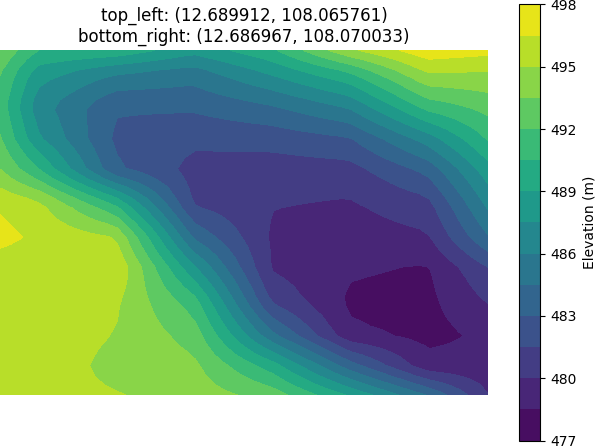

In [27]:
elev(top_left, bottom_right)

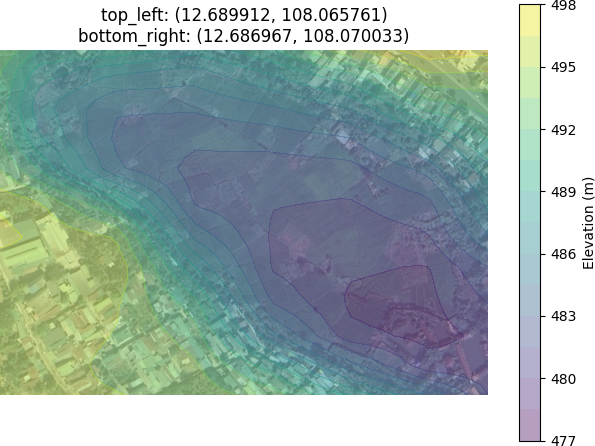

In [32]:
satElev(top_left, bottom_right)

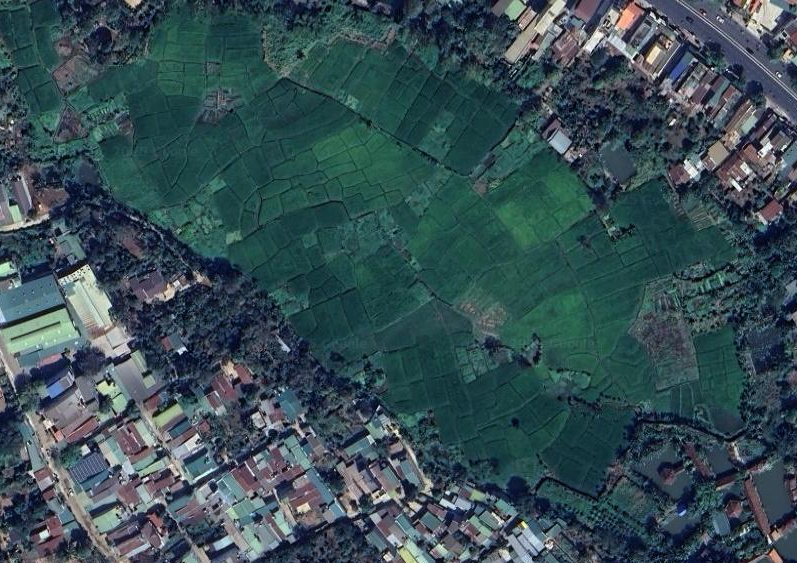

In [13]:
sat(top_left, bottom_right)

In [64]:
!../export.py kgis --upload=True

./export started up - /home/quang/miniforge3/bin/python
----- exportAll
17346   0   60%   
11419   1   40%   
installing...
Found existing installation: k1lib 1.8
Uninstalling k1lib-1.8:
  Successfully uninstalled k1lib-1.8
DEPRECATION: Loading egg at /home/quang/miniforge3/lib/python3.12/site-packages/aigu-0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
Looking in indexes: https://pypi.org/simple, http://10.104.0.3:3141/
Processing /home/quang/k1lib
  Preparing metadata (setup.py) ... done
  Created wheel for k1lib: filename=k1lib-1.8-py3-none-any.whl size=5158834 sha256=44d6304f87bab88535b25d20c78376b4af640a4cadb2985aa4c8325f25e46f0f
  Stored in directory: /tmp/pip-ephem-wheel-cache-2xk4pfjz/wheels/b5/32/67/e20c84dce16d707fb881c12d405f70adfaa36fe7dae9021380
Successfully built k1lib
installed
uploading...
uploaded


In [15]:
!../export.py kgis

./export started up - /home/quang/miniforge3/bin/python
----- exportAll
17074   0   60%   
11354   1   40%   
installing...
Found existing installation: k1lib 1.8
Uninstalling k1lib-1.8:
  Successfully uninstalled k1lib-1.8
DEPRECATION: Loading egg at /home/quang/miniforge3/lib/python3.12/site-packages/aigu-0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
Looking in indexes: https://pypi.org/simple, http://10.104.0.3:3141/
Processing /home/quang/k1lib
  Preparing metadata (setup.py) ... done
  Created wheel for k1lib: filename=k1lib-1.8-py3-none-any.whl size=5148446 sha256=1b48448b14357c375904cec9eab0424514b3745d0c209177e48cf40b3b31f633
  Stored in directory: /tmp/pip-ephem-wheel-cache-2fi49e0t/wheels/b5/32/67/e20c84dce16d707fb881c12d405f70adfaa36fe7dae9021380
Successfully built k1lib
installed


In [22]:
!../export.py kgis --bootstrap=True

Traceback (most recent call last):
  File "/home/quang/k1lib/k1lib/../export.py", line 10, in <module>
    try: from k1lib.imports import *; hasK1 = True
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/quang/k1lib/k1lib/__init__.py", line 35, in <module>
    from . import kgis;     kgis     = wrapMod(kgis)
    ^^^^^^^^^^^^^^^^^^
ImportError: cannot import name 'kgis' from partially initialized module 'k1lib' (most likely due to a circular import) (/home/quang/k1lib/k1lib/__init__.py)
./export started up - /home/quang/miniforge3/bin/python
----- bootstrapping
Current dir: /home/quang/k1lib, /home/quang/k1lib/k1lib/../export.py
installing...
Found existing installation: k1lib 1.8
Uninstalling k1lib-1.8:
  Successfully uninstalled k1lib-1.8
DEPRECATION: Loading egg at /home/quang/miniforge3/lib/python3.12/site-packages/aigu-0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at